# Тестирование и исправление MCLP

На задачах для оценки спроса

In [6]:
import random

import osmnx as ox
import geopandas as gpd
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Данные
g = ox.load_graphml("tests/data/test_rng.ml")
g = ox.simplify_graph(g)
area = gpd.read_file("tests/data/test_polygon.gpkg")

# здания
b = gpd.read_file("tests/data/buildings.gpkg", layer='здания')
b = b[['osmid', 'building', 'demand', 'geometry']]   # 'name', 'amenity', 
b = b.set_index('osmid')
print('Всего зданий:', len(b))

nodes = ox.graph_to_gdfs(g, edges=False)
area_nodes = nodes.within(area.iloc[0].geometry)
nodes_list=set(nodes[area_nodes].index)

print('Узлов в графе:', len(nodes))
print('Узлов в пределах area:', len(nodes_list))

Всего зданий: 1591
Узлов в графе: 1941
Узлов в пределах area: 950


In [3]:
print('Проверка СК:', end=' ')
if not g.graph['crs'] == b.crs:
    raise ValueError('CRS G и buildings различны!')
else:
    print('CRS совпадают.')

g = ox.project_graph(g)
b = ox.project_gdf(b)

print('Проверка СК:', end=' ')
if not g.graph['crs'] == b.crs:
    raise ValueError('CRS G и buildings различны!')
else:
    print('CRS совпадают.')

g_nodes = ox.graph_to_gdfs(g, edges=False)
b = b.sjoin_nearest(g_nodes[['geometry']], max_distance=100)
b.rename(columns={'index_right': 'node'}, inplace=True)

Проверка СК: CRS совпадают.


Проверка СК: CRS совпадают.


In [4]:
# Начальное размещение
units_count = 3
start_state = {random.sample(list(nodes_list), k=1)[0]:f'псч {i}' for i in range(units_count)}
start_state

{9085465258: 'псч 0', 9821639456: 'псч 1', 9086103735: 'псч 2'}

In [45]:
# ============================================================================
import math
import warnings
from fire_units.metrics import CoverIndexBuilding, Demand
from genesis.best_points import BestNodeHillClimbing
from genesis.core import BestPointsBase, LSCPBase, MCLPBase, MetricBase, PointSelectorBase, StateBase, StopCaseBase
from genesis.lscp import LSCPCommon
from genesis.mclp import BestNodesKoptG, BestNodesSA
from genesis.metrics import ArrivalTime
from genesis.point_selectors import FarNodeSelector, GenesisNodeSelector, RandomNodesSelector
from genesis.states import FirstArrivalUnitState
from genesis.stop_cases import ItersStopCase, MoreEqualStopCase, NSameStopCase
from genesis.tools import list_dict_concat
from genesis.utils import TimeCheckPoint, timing

# ============================================================================
class BestNodesGA(MCLPBase):
    '''
    Поиск лучших узлов для размещения n объектов.

    Расчет производится генетическим алгоритмом.

    ## Область применения
    Определение размещения множества узлов в графе, при котором 
    обеспечиваются наилучшие некоторые целевые метрики. 
    
    Дает решение высокой точности. Хорошо подходит для больших графов.
    '''

    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 node_selector:PointSelectorBase,
                 population_size:int = 25,
                 epochs:int = 50,
                 mutation_rate:float = 0.5,
                 elite_size:int = 0,
                 appr_val_in_area:float = 0,
                 mutation_max_count:int = 1,
                 bad_val_in_area:int = 1000,
                 epoch_end_function:callable = None,
                 stop_case_function:callable = None,
                 **kwargs) -> None:
        '''
        ## Аргументы
        `state_function`: StateBase
            функция расчета состояния окружения
        `metric_function`: MetricBase
            Функция расчета метрики
        `node_selector`: PointSelectorBase
            Функция выбора узла.
        `population_size`:int = 25
            Размер популяции
        `epochs`: int = 50
            Количество эпох расчета
        `mutation_rate`: float = 0.1
            Вероятность единичной мутации
        `elite_size`: int =  0
            Количество особей в элитной группе.
            Если указан 0, то механизм элитизма не задействуется.
        `appr_val_in_area`: int=0
            Доля узлов графа в пределах area, покрытие которой считается приемлемой для принятия расчетной метрики. 
            Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
            то такой узел не рассматривается.
            При расчет размещения нескольких узлов неминуемо возникает ситуация при которой
            часть территории area будет недостижима. Поэтому по умолчанию считается
        `mutation_max_count`: int = 1
            Максимальное количество единиц мутации.
        `bad_val_in_area`: int=1000
            Значение указываемое для узла, в случае если
            из него нельзя попасть в `appr_val_in_area` долю узлов в пределах
            `area`.
        `epoch_end_function`: callable = None
            Функция вызываемая после каждой эпохи расчета.
        `stop_case_function`: callable = None
            Функция проверки достигнута ли цель расчета
        '''
        if population_size <= 5:
            raise ValueError('Размер популяции должен быть > 0, так же не рекомендуется использовать размер популяции < 5')
        if epochs  <=  0:
            raise ValueError('Количество эпох должно быть > 0')
        if mutation_max_count  <=  0:
            raise ValueError('Максимальное количество единиц мутации должно быть > 0')
        if mutation_rate <0 or mutation_rate > 1:
            raise ValueError('Вероятность мутации должна лежать в диапазоне (0,1)')
        if appr_val_in_area <0 or appr_val_in_area > 1:
            raise ValueError('Доля узлов графа в пределах area, должна лежать в диапазоне (0,1)')
        if elite_size < 0:
            raise ValueError('Количество особей в элитной группе должно быть >= 0')
        
        self.population_size = population_size
        self.epochs = epochs
        self.mutation_rate = mutation_rate
        self.elite_size = elite_size
        self.appr_val_in_area = appr_val_in_area
        self.mutation_max_count = mutation_max_count
        self.bad_val_in_area = bad_val_in_area
        self.epoch_end_function = epoch_end_function
        self.stop_case_function = stop_case_function
        self.node_selector = node_selector
        super().__init__(state_function, metric_function, **kwargs)

    def _fit_function(self, env, nodes, area=None, **kwargs):
        '''
        Расчет функции приспособленности
        '''
        # 2.1. Расчет состояния
        times, _ = self.state_function(env=env, points=nodes, area=area, **kwargs)

        if not area is None:
            appr_nodes_count = area.sum() * self.appr_val_in_area
            if len(times) < appr_nodes_count:
                print('Расстановка не обеспечивает требуемую степень прикрытия территории area')
                return self.bad_val_in_area

        # 2.2. Расчет стартовой метрики состояния и определение стартового размещения
        best_metric = self.metric_function(times, **kwargs)

        return best_metric

    def _mutate(self, env, new_dynamic_nodes, area):
        '''
        Мутация особи
        '''
        for _ in range(self.mutation_max_count):
            if random.random() < self.mutation_rate:
                # Выбор случайного элемента в словаре и удаление его из new_dynamic_nodes
                node, unit = random.choice(list(new_dynamic_nodes.items()))
                del new_dynamic_nodes[node]

                # Поиск нового узла, которого при этом нет в new_dynamic_nodes
                node = self.node_selector(env=env, points=new_dynamic_nodes, area=area)
                # node = random.choice(g_nodes)
                # while node in new_dynamic_nodes.keys():
                #     node = random.choice(g_nodes)

                new_dynamic_nodes[node] = unit

        return  new_dynamic_nodes

    def __call__(self,
                 env:nx.MultiDiGraph,
                 dynamic_nodes: dict,
                 static_nodes: dict = None,
                 area: pd.Series = None,
                 **kwargs):
        '''
        Запуск работы генетического алгоритма

        ## Аргументы
        `env`:nx.MultiDiGraph
            Граф улично-дорожной сети
        `dynamic_nodes`: list|dict
            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.
        `static_nodes`: list|dict = None
            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        '''

        # 0. Проверка корректности пришедших данных
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип аргумента `env` должен быть `MultiDiGraph`!")
        if not isinstance(dynamic_nodes, dict):
            raise TypeError("Тип аргумента `dynamic_nodes` должен быть `dict`!")
        if not static_nodes is None and not isinstance(static_nodes, dict):
            raise TypeError("Тип аргумента `static_nodes` должен быть `dict`!")
        if len(dynamic_nodes) < 2:
            raise ValueError(f'Количество элементов `dynamic_nodes` не может быть меньше 2. Сейчас {len(dynamic_nodes)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')


        # 1.1. Если статические узлы не указаны - заменяем значение переменной с None
        # на {}
        if static_nodes is None:
            static_nodes = {}

        # Последовательность узлов графа (для последующего обращения к нему)
        g_nodes = list(env.nodes())

        # ===================================== Генетический алгоритм ==============
        # 1. Создание стартовой популяции
        population = [dynamic_nodes for _ in range(self.population_size)]
        # Оценка приспособленности всех особей
        bot_fit = [self._fit_function(env=env,
                                      nodes=list_dict_concat(dn, static_nodes),
                                      area=area,
                                      **kwargs) for dn in population]
        if self.metric_function.compare(1,2)==1:        # Для минимизации:
            max_val  = max(bot_fit)
            weights = [1.1*max_val-x for x in bot_fit]
            best_metric = min(bot_fit)
        else:                                           # Для максимизации:
            weights = bot_fit
            best_metric = max(bot_fit)
        best_bot = population[bot_fit.index(best_metric)]

        # 2. На каждой эпохе
        for epoch in range(self.epochs):

            # new_population = []
            # 2.1 Генерация новой популяции
            # for _ in range(self.population_size):
            #     # Элитарность
            #     if self.elite_size>0:
            #         # Определение весов
            #         pop_weight = pd.DataFrame({'w': weights, 'p': population})
            #         pop_weight = pop_weight.sort_values('w', ascending=False)
            #         pop_weight = pop_weight.iloc[:self.elite_size]
            #         population = pop_weight['p'].to_list()
            #         weights = pop_weight['w'].to_list()

            #     # Отбор по правилу рулетки
            #     parent_bot_1 = random.choices(population, weights=weights)[0]
            #     parent_bot_2 = random.choices(population, weights=weights)[0]

            #     # Скрещивание (одноточечное)
            #     split_point = int(len(parent_bot_1)/2)
            #     left_gen_vals = list(parent_bot_1.values())[:split_point]
            #     right_gen_vals  = list(parent_bot_1.values())[split_point:]
            #     left_genome_part = {k:v for k, v in parent_bot_1.items() if v in left_gen_vals}
            #     right_genome_part = {k:v for k, v in parent_bot_2.items() if v in right_gen_vals}
            #     new_dynamic_nodes = {**left_genome_part, **right_genome_part}

            #     # Мутация (выбор произвольного узла)
            #     new_dynamic_nodes = self._mutate(env=env,
            #                                      new_dynamic_nodes=new_dynamic_nodes,
            #                                      area=area)

            #     # Добавляем его в новую популяцию
            #     new_population.append(new_dynamic_nodes)

            # 2.0 Элитарность
            if self.elite_size>0:
                # Определение весов
                pop_weight = pd.DataFrame({'w': weights, 'p': population})
                pop_weight = pop_weight.sort_values('w', ascending=False)
                pop_weight = pop_weight.iloc[:self.elite_size]
                population = pop_weight['p'].to_list()
                weights = pop_weight['w'].to_list()
                
                new_population = population.copy()
            else:
                new_population = []

            # 2.1 Генерация новой популяции
            for _ in range(self.population_size - self.elite_size):
                # print(len(population), len(weights))

                # Отбор по правилу рулетки
                parent_bot_1 = random.choices(population, weights=weights)[0]
                parent_bot_2 = random.choices(population, weights=weights)[0]

                # Скрещивание (одноточечное)
                split_point = int(len(parent_bot_1)/2)
                left_gen_vals = list(parent_bot_1.values())[:split_point]
                right_gen_vals  = list(parent_bot_1.values())[split_point:]
                left_genome_part = {k:v for k, v in parent_bot_1.items() if v in left_gen_vals}
                right_genome_part = {k:v for k, v in parent_bot_2.items() if v in right_gen_vals}
                new_dynamic_nodes = {**left_genome_part, **right_genome_part}

                # Мутация (выбор произвольного узла)
                new_dynamic_nodes = self._mutate(env=env,
                                                 new_dynamic_nodes=new_dynamic_nodes,
                                                 area=area)

                # Добавляем его в новую популяцию
                new_population.append(new_dynamic_nodes)

            # 2.2 Заменяем предыдущую популяцию новой
            population = new_population

            # 2.3 Оценка приспособленности всех особей
            bot_fit = [self._fit_function(env=env,
                                      nodes=list_dict_concat(dn, static_nodes),
                                      area=area,
                                      **kwargs) for dn in population]

            # 2.4 Определение лучшего на эпохе значения метрики
            # и весов в зависимости от приспособленности        
            if self.metric_function.compare(1,2)==1:    # Для минимизации:
                max_val  = max(bot_fit)
                weights = [max_val-x for x in bot_fit]
                cur_metric = min(bot_fit)
            else:                                       # Для максимизации
                weights = bot_fit
                cur_metric = max(bot_fit)
            
            # 2.5 Нормализация весов (для более выраженной точности расчета)
            weights = (weights - np.min(weights)) / (np.max(weights) - np.min(weights))

            # 2.6 Определяем лучше ли лучшее на эпохе решение чем имеющееся
            if self.metric_function.compare(best_metric, cur_metric) == cur_metric:
                best_bot = population[bot_fit.index(cur_metric)]
                best_metric  = cur_metric

            # 2.7 Выполнение функции окончания расчета на эпохе
            if self.epoch_end_function:
                self.epoch_end_function(epoch=epoch,
                                        best_metric=best_metric,
                                        cur_metric=cur_metric,
                                        best_bot=best_bot)

            # 2.8 Если достигнута цель расчета, выходим из цикла
            if self.stop_case_function:
                if self.stop_case_function(value=best_metric,
                            iteration=epoch,
                            best_metric=best_metric,
                            dynamic_nodes=best_bot,
                            static_nodes=static_nodes):
                    break

        return best_bot, best_metric

class BestNodesSA(MCLPBase):
    '''
    Поиск лучших узлов для размещения n объектов.

    Расчет производится алгоритмом имитации отжига.

    ## Область применения
    Определение размещения множества узлов в графе, при котором 
    обеспечиваются наилучшие некоторые целевые метрики. 
    
    ### Достоинства
    Дает решение высокой точности. Подходит для средних графов.
    
    ### Недостатки
    Долго считает. 
    '''
    def __init__(self, state_function: StateBase,
                 metric_function: MetricBase,
                 node_selector:PointSelectorBase,
                 initial_temperature: float = 1,
                 end_temperature: float = 0.0001,
                 turns: int = 1000000,
                 mutation_max_count: int = 1,
                 appr_val_in_area: float = 0,
                 bad_val_in_area: int|None = 1000,
                 turn_end_function: callable = None,
                 best_state_find_function: callable = None,
                 stop_case_function: callable = None,
                 **kwargs) -> None:
        '''
        ## Аргументы
        `state_function`: StateBase
            функция расчета состояния окружения
        `metric_function`: MetricBase
            Функция расчета метрики
        `initial_temperature`: float  = 1
            Начальная температура
        `end_temperature`: float = 0.0001
            Конечная температура
        `mutation_max_count`: int = 1
            Максимальное количество единиц мутации.
        `appr_val_in_area`: int=0
            Доля узлов графа в пределах area, покрытие которой 
            считается приемлемой для принятия расчетной метрики. 
            Если при расчете метрик, из стартового узла (узлов) достижимо меньшее 
            количество узлов, то такой узел не рассматривается.
            При расчет размещения нескольких узлов неминуемо возникает ситуация при которой
            часть территории area будет недостижима. Поэтому по умолчанию считается
        `bad_val_in_area`: int=1000
            Значение указываемое для узла, в случае если
            из него нельзя попасть в `appr_val_in_area` долю узлов в пределах
            `area`.
        `turn_end_function`: callable  = None
            Функция вызываемая на каждой итерации расчета.
        `best_state_find_function`: callable = None
            Функция вызываемая после каждого улучшения абсолютного оптимума.
        '''

        if initial_temperature  <  0:
            raise ValueError('Начальная температура должна быть >= 0')
        if end_temperature  <  0:
            raise ValueError('Конечная температура должна быть >= 0')
        if end_temperature  >  initial_temperature:
            raise ValueError('Конечная температура должна быть <= начальной')
        if mutation_max_count  <=  0:
            raise ValueError('Максимальное количество единиц мутации должно быть > 0')
        if appr_val_in_area < 0 or appr_val_in_area > 1:
            raise ValueError('Доля узлов графа в пределах area, должна лежать в диапазоне (0,1)')

        if turn_end_function:
            try:
                turn_end_function(turn = None,
                                        T = None,
                                        best_metric = None,
                                        cur_metric = None,
                                        best_bot = None)
            except TypeError:
                print('Сигнатура функции `turn_end_function` должна быть:')
                print('`turn_end_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict)`')
        
        if best_state_find_function:
            try:
                best_state_find_function(turn = None,
                                    T = None,
                                    best_metric = None,
                                    cur_metric = None,
                                    best_bot = None)
            except TypeError:
                print('Сигнатура функции `best_state_find_function` должна быть:')
                print('`best_state_find_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict)`')

        self.initial_temperature = initial_temperature
        self.end_temperature = end_temperature
        self.node_selector = node_selector
        self.turns = turns
        self.appr_val_in_area = appr_val_in_area
        self.mutation_max_count = mutation_max_count
        self.bad_val_in_area = bad_val_in_area
        self.turn_end_function = turn_end_function
        self.best_state_find_function = best_state_find_function
        self.stop_case_function = stop_case_function
        super().__init__(state_function, metric_function, **kwargs)


    def _decrease_temperature(self, T0, t):
        '''
        Функция изменения температуры

        ## Аргументы
        `T0` - начальная температура

        `t` - текущая итерация

        ## Возвращает
        Температура на итерации t
        '''
        return T0/(1+t)

    def _get_transition_probability(self, dE, T):
        '''
        Функция расчета вероятности перехода из состояния i в состояние j

        ## Аргументы
        `dE` - энергия перехода

        `T` - температура

        ## Возвращает
        Вероятность перехода
        '''
        try:
            return math.exp(-dE/T)
        except OverflowError as _:
            # print(dE, T)
            return 0
            # raise OverflowError(dE, T)

    def _calculate_energy(self, env: nx.MultiDiGraph, nodes: list, area=None, **kwargs):
        '''
        Расчет энергии состояния.
        Здесь это значение целевой метрики.

        ## Аргументы
        `env`: nx.MultiDiGraph
            окружение
        `nodes`: list
            список стартовых узлов. Например мест размещения пожарных депо
        `area`: pd.Series
            маска доступности узлов
        `**kwargs` - дополнительные аргументы
        '''
        # 1. Расчет состояния
        times, _ = self.state_function(env=env, points=nodes, area=area, **kwargs)

        if not area is None:
            appr_nodes_count = area.sum() * self.appr_val_in_area
            if len(times) < appr_nodes_count:
                print('Расстановка не обеспечивает требуемую степень прикрытия территории area')
                return self.bad_val_in_area

        # 2. Расчет стартовой метрики состояния и определение стартового размещения
        best_metric = self.metric_function(times, **kwargs)

        return best_metric

    def _generate_state_candidate(self, env, state, area):
                              #  (self, env, new_dynamic_nodes, g_nodes, area):
        '''
        Функция порождает новое состояние
        '''
        new_state = state.copy()

        # Здесь вся магия
        for _ in range(self.mutation_max_count):
            # Выбор случайного элемента в словаре и удаление его из new_state
            node, unit = random.choice(list(new_state.items()))
            del new_state[node]

            # Поиск нового узла, которого при этом нет в new_state
            node = self.node_selector(env=env, points=new_state, area=area)
            # node = random.choice(g_nodes)
            # while node in new_state.keys():
            #     node = random.choice(g_nodes)

            new_state[node] = unit

        # Возвращаем новое состояние
        return new_state

    def _is_transition(self, probability):
        value = random.random()
        return value <= probability

    def __call__(self,
                 env,
                 dynamic_nodes: dict,
                 static_nodes: dict = None,
                 area=None,
                 **kwargs):
        '''
        Запуск работы алгоритма имитации отжига

        ## Аргументы
        `env`:nx.MultiDiGraph
            Граф улично-дорожной сети
        `dynamic_nodes`: dict
            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.
        `static_nodes`: dict = None
            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        '''

        # 0. Проверяем пришедшие данные
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип аргумента `env` должен быть `MultiDiGraph`!")
        if not isinstance(dynamic_nodes, dict):
            raise TypeError("Тип аргумента `dynamic_nodes` должен быть `dict`!")
        if not static_nodes is None and not isinstance(static_nodes, dict):
            raise TypeError("Тип аргумента `static_nodes` должен быть `dict`!")
        if len(dynamic_nodes) < 1:
            raise ValueError(f'Количество элементов `dynamic_nodes` не может быть меньше 1. Сейчас {len(dynamic_nodes)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')
        if len(dynamic_nodes)<1:
            raise ValueError(f'Количество элементов `dynamic_nodes` не может быть равно 0! Сейчас {len(dynamic_nodes)}')

        if static_nodes is None:
            static_nodes = {}
        g_nodes = list(env.nodes())

        # 1. Рассчитываем исходное состояние и энергию, устанавливаем начальную температуру
        best_state = dynamic_nodes
        current_state = dynamic_nodes

        current_energy = self._calculate_energy(env=env,
                                      nodes=list_dict_concat(current_state, static_nodes),
                                      area=area,
                                      **kwargs)
        best_energy = current_energy
        T = self.initial_temperature

        # 2. Выполняем расчет
        for i in range(self.turns):
            state_candidate  = self._generate_state_candidate(env=env,
                                                             state=current_state,
                                                             area=area)
            candidate_energy = self._calculate_energy(env=env,
                                nodes=list_dict_concat(state_candidate, static_nodes),
                                area=area,
                                **kwargs)

            if current_energy != candidate_energy and \
                    self.metric_function.compare(current_energy, candidate_energy) == candidate_energy:
                current_energy = candidate_energy
                current_state = state_candidate

                if best_energy != current_energy and \
                    self.metric_function.compare(best_energy, current_energy) == current_energy: # Здесь проверку на тип оптимизации (мин/макс)
                    best_energy = current_energy
                    best_state = state_candidate

                    # Выполнение функции окончания расчета на эпохе
                    if self.best_state_find_function:
                        self.best_state_find_function(turn=i,
                                                T = T,
                                                best_metric=best_energy,
                                                cur_metric=candidate_energy,
                                                best_bot=best_state)
            else:
                p = self._get_transition_probability(candidate_energy-current_energy, T)
                if self._is_transition(p):
                    current_energy = candidate_energy
                    current_state = state_candidate

            T = self._decrease_temperature(self.initial_temperature, i)
            if T < self.end_temperature:
                return best_state, best_energy

            # Выполнение функции окончания расчета на эпохе
            if self.turn_end_function:
                self.turn_end_function(turn = i,
                                        T = T,
                                        best_metric = best_energy,
                                        cur_metric = candidate_energy,
                                        best_bot = best_state)
                
            # 2.8 Если достигнута цель расчета, выходим из цикла
            if self.stop_case_function:
                if self.stop_case_function(value=best_energy,
                            iteration=i,
                            best_metric=best_energy,
                            dynamic_nodes=best_state,
                            static_nodes=static_nodes):
                    break

        return best_state, best_energy


class BestNodesGAKopt(MCLPBase):
    '''
    Поиск лучших узлов для размещения n объектов.

    Расчет производится генетическим алгоритмом.
    При этом приспособленность каждой особи дополнительно
    улучшается за счет поиска наилучшего размещения динамических узлов
    при помощи алгоритма Kopt.

    ## Область применения
    Определение размещения множества узлов в графе, при котором 
    обеспечиваются наилучшие некоторые целевые метрики. 
    
    Дает решение высокой точности. Хорошо подходит для больших графов.
    '''

    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 kopt_function: BestNodesKoptG,
                 node_selector:PointSelectorBase,
                 population_size:int = 25,
                 epochs:int = 50,
                 mutation_rate:float = 0.5,
                 elite_size:int = 0,
                 appr_val_in_area:float = 0,
                 mutation_max_count:int = 1,
                 bad_val_in_area:int = 1000, # &! Возможна ошибка при возрастающих метриках...
                 epoch_end_function:callable = None,
                 stop_case_function:callable = None,
                 **kwargs) -> None:
        '''
        ## Аргументы
        `state_function`: StateBase
            функция расчета состояния окружения
        `metric_function`: MetricBase
            Функция расчета метрики
        `population_size`:int = 25
            Размер популяции
        `epochs`: int = 50
            Количество эпох расчета
        `mutation_rate`: float = 0.1
            Вероятность единичной мутации
        `elite_size`: int =  0
            Количество особей в элитной группе.
            Если указан 0, то механизм элитизма не задействуется.
        `appr_val_in_area`: int=0
            Доля узлов графа в пределах area, покрытие которой считается приемлемой для принятия расчетной метрики. 
            Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
            то такой узел не рассматривается.
            При расчет размещения нескольких узлов неминуемо возникает ситуация при которой
            часть территории area будет недостижима. Поэтому по умолчанию считается
        `mutation_max_count`: int = 1
            Максимальное количество единиц мутации.
        `bad_val_in_area`: int=1000
            Значение указываемое для узла, в случае если
            из него нельзя попасть в `appr_val_in_area` долю узлов в пределах
            `area`.
        `epoch_end_function`: callable = None
            Функция вызываемая после каждой эпохи расчета.
        '''
        if population_size <= 5:
            raise ValueError('Размер популяции должен быть > 0, так же не рекомендуется использовать размер популяции < 5')
        if epochs  <=  0:
            raise ValueError('Количество эпох должно быть > 0')
        # if mutation_max_count  <=  0:
        #     raise ValueError('Максимальное количество единиц мутации должно быть > 0')
        if mutation_rate <0 or mutation_rate > 1:
            raise ValueError('Вероятность мутации должна лежать в диапазоне (0,1)')
        if appr_val_in_area <0 or appr_val_in_area > 1:
            raise ValueError('Доля узлов графа в пределах area, должна лежать в диапазоне (0,1)')
        if elite_size < 0:
            raise ValueError('Количество особей в элитной группе должно быть >= 0')

        self.kopt_function = kopt_function
        self.population_size = population_size
        self.node_selector = node_selector
        self.epochs = epochs
        self.mutation_rate = mutation_rate
        self.elite_size = elite_size
        self.appr_val_in_area = appr_val_in_area
        self.mutation_max_count = mutation_max_count
        self.bad_val_in_area = bad_val_in_area
        self.epoch_end_function = epoch_end_function
        self.stop_case_function = stop_case_function
        super().__init__(state_function, metric_function, **kwargs)

    def _fit_function(self, env, nodes, area=None, **kwargs):
        '''
        Расчет функции приспособленности
        '''
        # 2.1. Расчет состояния
        times, _ = self.state_function(env=env, points=nodes, area=area, **kwargs)

        if not area is None:
            appr_nodes_count = area.sum() * self.appr_val_in_area
            if len(times) < appr_nodes_count:
                print('Расстановка не обеспечивает требуемую степень прикрытия территории area')
                return self.bad_val_in_area

        # 2.2. Расчет стартовой метрики состояния и определение стартового размещения
        best_metric = self.metric_function(times, **kwargs)

        return best_metric

    # def _mutate(self, new_dynamic_nodes, g_nodes):
    def _mutate(self, env, new_dynamic_nodes, area):
        # for _ in range(self.mutation_max_count):
        if self.mutation_max_count>0:
            mutation_count = self.mutation_max_count
        else:
            mutation_count = len(new_dynamic_nodes)
        for _ in range(mutation_count):
            if random.random() < self.mutation_rate:
                # Выбор случайного элемента в словаре и удаление его из new_dynamic_nodes
                node, unit = random.choice(list(new_dynamic_nodes.items()))
                del new_dynamic_nodes[node]

                # Поиск нового узла, котрого при этом нет в new_dynamic_nodes
                node = self.node_selector(env=env, points=new_dynamic_nodes, area=area)
                # node = random.choice(g_nodes)
                # while node in new_dynamic_nodes.keys():
                #     node = random.choice(g_nodes)

                new_dynamic_nodes[node] = unit

        return  new_dynamic_nodes


    def __call__(self,
                 env:nx.MultiDiGraph,
                 dynamic_nodes: dict,
                 static_nodes: dict = None,
                 area: pd.Series = None,
                 **kwargs):
        '''
        Запуск работы генетического алгоритма

        ## Аргументы
        `env`:nx.MultiDiGraph
            Граф улично-дорожной сети
        `dynamic_nodes`: list|dict
            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.
        `static_nodes`: list|dict = None
            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        '''

        # 0. Проверка корректности пришедших данных
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип аргумента `env` должен быть `MultiDiGraph`!")
        if not isinstance(dynamic_nodes, dict):
            raise TypeError("Тип аргумента `dynamic_nodes` должен быть `dict`!")
        if not static_nodes is None and not isinstance(static_nodes, dict):
            raise TypeError("Тип аргумента `static_nodes` должен быть `dict`!")
        if len(dynamic_nodes) < 2:
            raise ValueError(f'Количество элементов `dynamic_nodes` не может быть меньше 2. Сейчас {len(dynamic_nodes)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')


        # 1.1. Если статические узлы не указаны - заменяем значение переменной с None
        # на {}
        if static_nodes is None:
            static_nodes = {}

        # Последовательность узлов графа (для последующего обращения к нему)
        g_nodes = list(env.nodes())

        # ===================================== Генетический алгоритм ==============
        # 1. Создание стартовой популяции
        population = [dynamic_nodes for _ in range(self.population_size)]
        # Оценка приспособленности всех особей
        bot_fit = [self._fit_function(env=env,
                                      nodes=list_dict_concat(dn, static_nodes),
                                      area=area,
                                      **kwargs) for dn in population]
        if self.metric_function.compare(1,2)==1:        # Для минимизации:
            max_val  = max(bot_fit)
            weights = [1.1*max_val-x for x in bot_fit]
            best_metric = min(bot_fit)
        else:                                           # Для максимизации:
            weights = bot_fit
            best_metric = max(bot_fit)
        best_bot = population[bot_fit.index(best_metric)]

        # 2. На каждой эпохе
        for epoch in range(self.epochs):


            # 2.0 Элитарность
            if self.elite_size>0:
                # Определение весов
                pop_weight = pd.DataFrame({'w': weights, 'p': population})
                pop_weight = pop_weight.sort_values('w', ascending=False)
                pop_weight = pop_weight.iloc[:self.elite_size]
                population = pop_weight['p'].to_list()
                weights = pop_weight['w'].to_list()
                
                new_population = population.copy()
            else:
                new_population = []




            # 2.1 Генерация новой популяции
            for _ in range(self.population_size - self.elite_size):
                # print(len(population), len(weights))

                # Отбор по правилу рулетки
                parent_bot_1 = random.choices(population, weights=weights)[0]
                parent_bot_2 = random.choices(population, weights=weights)[0]

                # Скрещивание (одноточечное)
                split_point = int(len(parent_bot_1)/2)
                left_gen_vals = list(parent_bot_1.values())[:split_point]
                right_gen_vals  = list(parent_bot_1.values())[split_point:]
                left_genome_part = {k:v for k, v in parent_bot_1.items() if v in left_gen_vals}
                right_genome_part = {k:v for k, v in parent_bot_2.items() if v in right_gen_vals}
                new_dynamic_nodes = {**left_genome_part, **right_genome_part}

                # Мутация (выбор произвольного узла)
                # new_dynamic_nodes = self._mutate(new_dynamic_nodes, g_nodes)
                new_dynamic_nodes = self._mutate(env=env,
                                                 new_dynamic_nodes=new_dynamic_nodes,
                                                 area=area)

                # Добавляем его в новую популяцию
                new_population.append(new_dynamic_nodes)

            # 2.2 Заменяем предыдущую популяцию новой
            population = new_population

            # 2.3 Оценка приспособленности всех особей
            bot_fit = [self._fit_function(env=env,
                                      nodes=list_dict_concat(dn, static_nodes),
                                      area=area,
                                      **kwargs) for dn in population]

            # 2.4 Определение лучшего на эпохе значения метрики
            # и весов в зависимости от приспособленности        
            if self.metric_function.compare(1,2)==1:    # Для минимизации:
                max_val  = max(bot_fit)
                weights = [max_val-x for x in bot_fit]
                cur_metric = min(bot_fit)
            else:                                       # Для максимизации
                weights = bot_fit
                cur_metric = max(bot_fit)
            # 2.5 Нормализация весов (для более выраженной точности расчета)
            weights = (weights - np.min(weights)) / (np.max(weights) - np.min(weights))

            # 2.6 Определяем лучше ли лучшее на эпохе решение чем имеющееся
            if self.metric_function.compare(best_metric, cur_metric) == cur_metric:
                best_bot = population[bot_fit.index(cur_metric)]
                best_metric  = cur_metric

            # 2.7 Выполнение функции окончания расчета на эпохе
            if self.epoch_end_function:
                self.epoch_end_function(epoch=epoch,
                                        best_metric=best_metric,
                                        cur_metric=cur_metric,
                                        best_bot=best_bot)
                
            # 2.8 Если достигнута цель расчета, выходим из цикла
            if self.stop_case_function:
                if self.stop_case_function(value=best_metric,
                            iteration=epoch,
                            best_metric=best_metric,
                            dynamic_nodes=best_bot,
                            static_nodes=static_nodes):
                    # return best_bot, best_metric
                    break
            
        # Применение чистовой обработки с использованием локального поиска
        best_bot, best_metric = self.kopt_function(
            env = env,
            dynamic_nodes = best_bot,
            static_nodes = static_nodes,
            area = area,
        )

        return best_bot, best_metric





# ============================================================================


# функции метрик спроса
# metric_funct = Demand(b, buildings_demand_field='demand')
# metric_funct = CoverIndexBuilding(b)
# metric_funct = CoverIndexBuilding(b, ip_val=5)
metric_funct = ArrivalTime()

print('\n', '# GNS')
print('-'*80)
t = TimeCheckPoint()
# t2 = TimeCheckPoint()

# здесь сам расчет
def epoch_end_function(epoch, best_metric, cur_metric, best_bot, **kwargs):
    best_bot = {k:v for k,v in sorted(best_bot.items(), key=lambda item: item[1])}
    print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |', best_bot)

def step_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict):
        print(f'Шаг: {turn} |', f'T={T} |', f'Лучшая метрика: {best_metric} |', f'Лучшее положение: {best_bot} |', ' '*10, end='\r')
def best_state_find_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict):
        print(f'\nШаг: {turn} |', f'T={T} |', f'Лучшая метрика: {best_metric} |', f'Лучшее положение: {best_bot} |')

def iter_calc_end_function(i, best_metric, **kwargs):
    print(f'Итерация: {i} |', f'Лучшая метрика: {best_metric} |', ' '*10)  #, end='\r')





# Случай остановки
# stop_case = MoreEqualStopCase(95)
stop_case = NSameStopCase(15)
stop_case = ItersStopCase(5)

# Селектор следующей точки
point_selector = RandomNodesSelector(nodes_list=nodes_list)
# point_selector = GenesisNodeSelector(state_function = FirstArrivalUnitState(),
#                                     metric_function = metric_funct)
# point_selector = FarNodeSelector(FirstArrivalUnitState(), nodes_list=nodes_list)

# Сборка алгоритма
# mclp = timing(BestNodesGA(FirstArrivalUnitState(),
#                    metric_function = metric_funct,
#                    node_selector = point_selector,
#                    population_size=100,
#                    elite_size = 10,
#                    epochs = 30,
#                    mutation_rate = 0.5,
#                    mutation_max_count=3,
#                    epoch_end_function = epoch_end_function,
#                 #    stop_case_function=stop_case,
#                    ))

# mclp = timing(BestNodesSA(FirstArrivalUnitState(),
#                           metric_function=metric_funct,
#                           node_selector = point_selector,
#                         #   end_temperature=0.001,
#                           mutation_max_count=3,
#                           turn_end_function=step_function,
#                           best_state_find_function=best_state_find_function,
#                           ))

bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                   metric_function=metric_funct,                      
                    )
kopt = BestNodesKoptG(FirstArrivalUnitState(),
                          metric_function=metric_funct,
                          best_point_function=bnhc,
                          iterations=3,
                          iter_calc_end_function=iter_calc_end_function,
                          )

mclp = timing(BestNodesGAKopt(FirstArrivalUnitState(),
                          metric_function=metric_funct,
                          kopt_function = kopt,
                          node_selector = point_selector,
                          population_size=100,
                          elite_size = 15,
                          epochs = 50,
                          mutation_rate = 0.5,
                          mutation_max_count=3,
                          epoch_end_function = epoch_end_function,
                          #    stop_case_function=stop_case,
))

# Собственно применения построенного алгоритма
optimal_nodes, best_metric = mclp(env=g,
                                #   static_nodes=existed_units, 
                                  dynamic_nodes=start_state,
                                  area=area_nodes,
                                  )


 # GNS
--------------------------------------------------------------------------------
Эпоха: 0 | Лучшая метрика: 2.999978152491344 | Текущая метрика: 2.999978152491344 | {9085465258: 'псч 0', 5574296110: 'псч 1', 8922666360: 'псч 2'}
Эпоха: 1 | Лучшая метрика: 2.9566457469516783 | Текущая метрика: 2.9566457469516783 | {1577701962: 'псч 0', 2034401362: 'псч 1', 9086103735: 'псч 2'}
Эпоха: 2 | Лучшая метрика: 2.9070525091073307 | Текущая метрика: 2.9070525091073307 | {9085465258: 'псч 0', 2034401362: 'псч 1', 4850965880: 'псч 2'}
Эпоха: 3 | Лучшая метрика: 2.9070525091073307 | Текущая метрика: 2.9070525091073307 | {9085465258: 'псч 0', 2034401362: 'псч 1', 4850965880: 'псч 2'}
Эпоха: 4 | Лучшая метрика: 2.808387685082041 | Текущая метрика: 2.808387685082041 | {2034401394: 'псч 0', 426923857: 'псч 1', 1644098168: 'псч 2'}
Эпоха: 5 | Лучшая метрика: 2.7672048046063527 | Текущая метрика: 2.7672048046063527 | {9086101204: 'псч 0', 2034401362: 'псч 1', 1545620171: 'псч 2'}
Эпоха: 6 | Лучша

2.7174037347583924


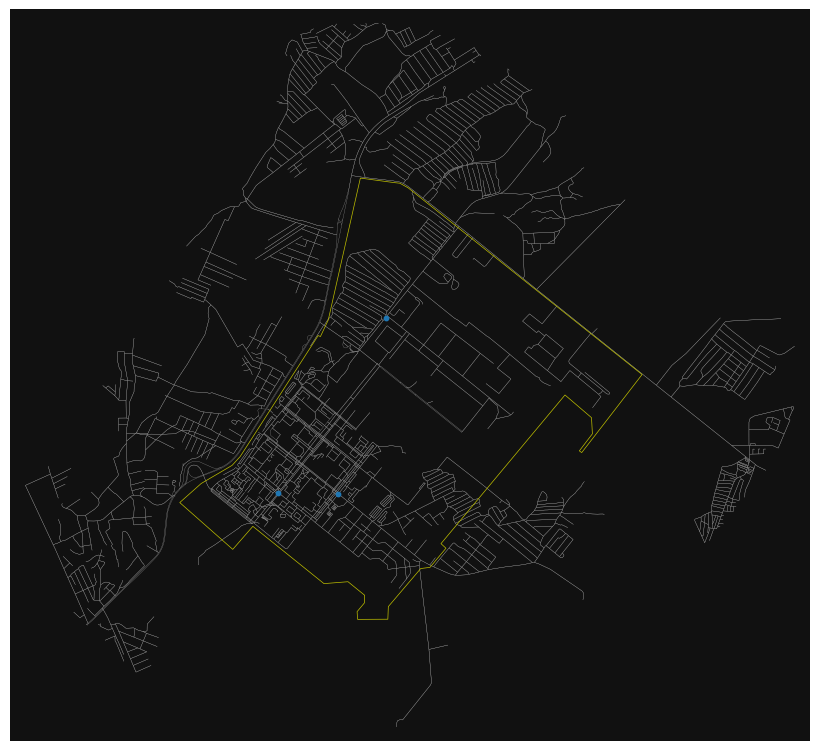

In [41]:
print(best_metric)

# Сопоставление локальных оптимумов со значениями метрик в них
nodes_gdf = ox.graph_to_gdfs(g, edges=False)
# locals = nodes_gdf.loc[optimums_list].copy()
# locals['demand_metric'] = optimums_metrics
units = nodes_gdf.loc[optimal_nodes.keys()]

# Печать карты
# fig, ax = plt.subplots(1, 1, figsize=(8, 8))
fig, ax = ox.plot_graph(g, node_size=0, edge_linewidth=0.2, show=False)
ox.project_gdf(area).boundary.plot(ax=ax, linewidth=0.5, color='y')
units.plot(ax=ax, markersize=10, legend=True)

plt.tight_layout(pad=0)
plt.show()